# Bài 1: Linh tinh

#

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(420)
n_samples = 100

data = {
    'Age': np.random.choice([25, 30, 35, 40, np.nan, 50, 60], size=n_samples),
    'Income': np.random.exponential(scale=50000, size=n_samples), # Skewed data + Outliers
    'Education': np.random.choice(['High School', 'Bachelor', 'Master', np.nan], size=n_samples), # Ordinal
    'City': np.random.choice(['Hanoi', 'HCM', 'Danang', np.nan], size=n_samples), # Nominal
    'Target': np.random.choice([0, 1], size=n_samples, p=[0.7, 0.3]) # Label
}

df_raw = pd.DataFrame(data)

# Intentionally inject 2 outliers
df_raw.loc[0, 'Income'] = 1_500_000
df_raw.loc[1, 'Income'] = 2_000_000

print(df_raw.head())

    Age        Income Education   City  Target
0  30.0  1.500000e+06    Master  Hanoi       0
1  25.0  2.000000e+06  Bachelor    HCM       1
2  60.0  3.959068e+03  Bachelor  Hanoi       1
3  40.0  4.528585e+04       nan    nan       0
4  60.0  9.994209e+03  Bachelor    HCM       0


# Nhiệm vụ 1: Chia tập dữ liệu
Chia df_raw thành tập X (đặc trưng) và y (Target). Sau đó dùng train_test_split chia thành X_train, X_test, y_train, y_test với tỉ lệ $80/20$.

In [ ]:
from sklearn.model_selection import train_test_split
X = df_raw.drop('Target', axis=1)
y = df_raw['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (80, 4)
Shape of X_test: (20, 4)
Shape of y_train: (80,)
Shape of y_test: (20,)


# Nhiệm vụ 2: Xử lý Outliers trên tập Train bằng kỹ thuật IQR Capping
Viết một hàm hoặc class dùng phương pháp $IQR$ ($Q_1 - 1.5 \times IQR$ đến $Q_3 + 1.5 \times IQR$) để Capping (giới hạn) các giá trị ngoại lai trên cột Income.Lưu ý: $Q_1$ và $Q_3$ phải được tính chỉ trên X_train['Income'] và dùng ngưỡng đó áp dụng cho cả X_test.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bound_ = None
        self.upper_bound_ = None

    def fit(self, X, y=None):
        X_arr = np.asarray(X)
        q1 = np.nanpercentile(X_arr, 25, axis=0)
        q3 = np.nanpercentile(X_arr, 75, axis=0)
        iqr = q3 - q1

        self.lower_bound_ = q1 - self.factor * iqr
        self.upper_bound_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_arr = np.asarray(X).copy()
        return np.clip(X_arr, self.lower_bound_, self.upper_bound_)

# Nhiệm vụ 3: Mã hóa Ordinal Feature (Education)
Tạo sơ đồ ánh xạ (dictionary mapping):
'High School': 1, 'Bachelor': 2, 'Master': 3.
Điền các giá trị thiếu trong cột Education bằng giá trị 1 (mức mặc định), sau đó chuyển đổi thành dạng số.

# Nhiệm vụ 4: Xử lý Pipeline tự động cho các cột còn lại bằng ColumnTransformer
Sử dụng sklearn.compose.ColumnTransformer kết hợp với Pipeline để xử lý song song:

1. Cột số (Age): Điền thiếu bằng SimpleImputer(strategy='median'), sau đó chuẩn hóa bằng StandardScaler().

2. Cột số bị skewed (Income): Điền thiếu bằng SimpleImputer(strategy='median'), sau đó chuẩn hóa bằng RobustScaler().

3. Cột chuỗi (City): Điền thiếu bằng SimpleImputer(strategy='most_frequent'), sau đó dùng OneHotEncoder(drop='first', handle_unknown='ignore').

In [ ]:
edu_map = {'High School': 1, 'Bachelor': 2, 'Master': 3}
X_train['Education'] = X_train['Education'].map(edu_map).fillna(1)
X_test['Education'] = X_test['Education'].map(edu_map).fillna(1)

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_age_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_income_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_city_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('age_pipe', numeric_age_pipeline, ['Age']),
    ('income_pipe', numeric_income_pipeline, ['Income']),
    ('passthrough_edu', 'passthrough', ['Education']), # Đã encode ở Bước 3
    ('city_pipe', categorical_city_pipeline, ['City'])
])

#Nhiệm vụ 5: Đóng gói và biến đổi dữ liệu hoàn chỉnh
Thực hiện .fit_transform() trên X_train và .transform() trên X_test.

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nKích thước tập Train sau tiền xử lý:", X_train_processed.shape)
print("Kích thước tập Test sau tiền xử lý:", X_test_processed.shape)
print("\nSample row từ tập Train đã xử lý:\n", X_train_processed[0])


Kích thước tập Train sau tiền xử lý: (80, 6)
Kích thước tập Test sau tiền xử lý: (20, 6)

Sample row từ tập Train đã xử lý:
 [ 1.63724838 -0.47984751  1.          0.          1.          0.        ]


In [ ]:
feature_names = preprocessor.get_feature_names_out()
print("Danh sách các cột sau biến đổi:")
print(feature_names)

Danh sách các cột sau biến đổi:
['age_pipe__Age' 'income_pipe__Income' 'passthrough_edu__Education'
 'city_pipe__City_HCM' 'city_pipe__City_Hanoi' 'city_pipe__City_nan']


# Chuẩn hoá L1 và L2 (L1 and L2 regularization)
tldr: punishing complex weights

L1: sparse weights (many weights = 0) --> can be understood as feature selection

L2: minimize all weights but rarely goes down to 0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print(f"Kích thước tập dữ liệu: {X.shape}")

Kích thước tập dữ liệu: (178, 13)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42096, stratify=y)

In [ ]:
# Phải scale dữ liệu khi dùng Regularization
# Regularization nhạy cảm với thang đo của dữ liệu, nên ta phải chuẩn hóa về mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# No regularization
lr_none = LogisticRegression(penalty=None, max_iter=1000, random_state=42096)
lr_none.fit(X_train_scaled, y_train)
# L1 regularization, liblinear or saga solvers support L1 regularization
# C = 1/alpha, smaller C corresponds to greater penalty
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, max_iter=1000, random_state=42096)
lr_l1.fit(X_train_scaled, y_train)
# Mô hình L2 Regularization
lr_l2 = LogisticRegression(penalty='l2', solver='lbfgs', C=0.5, max_iter=1000, random_state=42096)
lr_l2.fit(X_train_scaled, y_train)

LogisticRegression(C=0.5, max_iter=1000, random_state=42096)

In [ ]:
# eval
print(f"Độ chính xác (Không Regularization): {accuracy_score(y_test, lr_none.predict(X_test_scaled)):.4f}")
print(f"Độ chính xác (L1 Regularization):  {accuracy_score(y_test, lr_l1.predict(X_test_scaled)):.4f}")
print(f"Độ chính xác (L2 Regularization):  {accuracy_score(y_test, lr_l2.predict(X_test_scaled)):.4f}")

Độ chính xác (Không Regularization): 0.9722
Độ chính xác (L1 Regularization):  1.0000
Độ chính xác (L2 Regularization):  1.0000


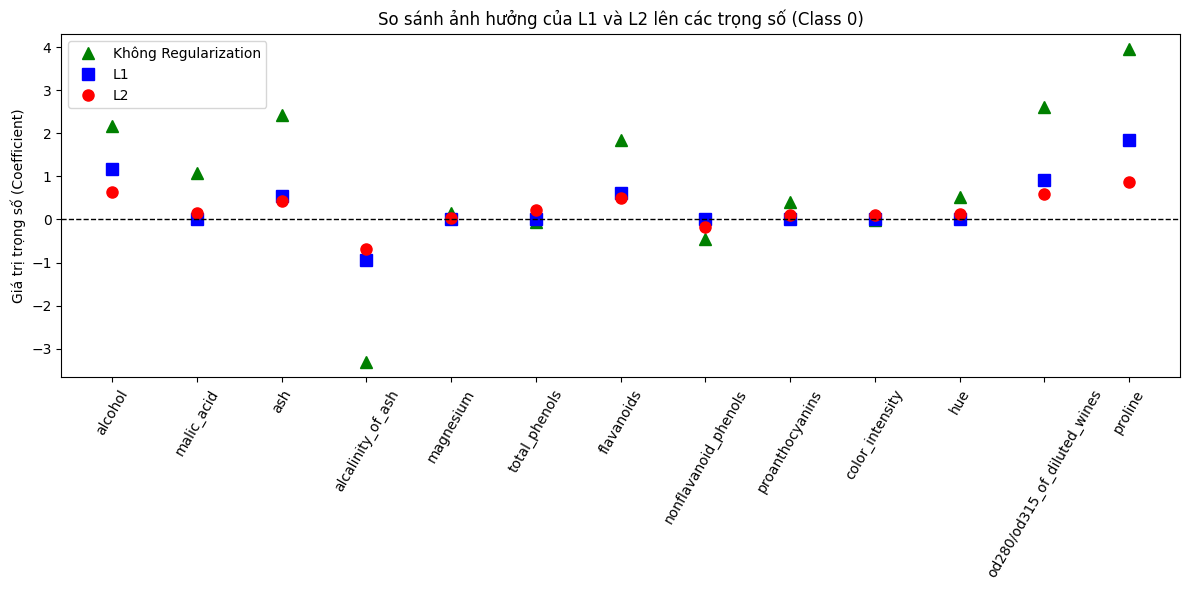

- L1 Regularization:  18
- L2 Regularization:  0
=== BẢNG SO SÁNH TRỌNG SỐ (WEIGHTS) CỦA CLASS 0 ===
         Đặc trưng (Feature)  Không Reg  L1 (Lasso)  L2 (Ridge)
                     alcohol     2.1769      1.1615      0.6456
                  malic_acid     1.0689      0.0000      0.1386
                         ash     2.4285      0.5458      0.4207
           alcalinity_of_ash    -3.3044     -0.9452     -0.6770
                   magnesium     0.1556      0.0000      0.0250
               total_phenols    -0.0633      0.0000      0.2176
                  flavanoids     1.8438      0.6097      0.4952
        nonflavanoid_phenols    -0.4602      0.0000     -0.1692
             proanthocyanins     0.3955      0.0000      0.1085
             color_intensity    -0.0102      0.0000      0.1103
                         hue     0.5188      0.0000      0.1314
od280/od315_of_diluted_wines     2.6053      0.9191      0.5882
                     proline     3.9464      1.8347      0.8810


In [ ]:
# comparing coefficients
coef_none = lr_none.coef_[0]
coef_l1 = lr_l1.coef_[0]
coef_l2 = lr_l2.coef_[0]

plt.figure(figsize=(12, 6))
x_idx = np.arange(len(wine.feature_names))

plt.plot(x_idx, coef_none, 'g^', label='Không Regularization', markersize=8)
plt.plot(x_idx, coef_l1, 'bs', label='L1', markersize=8)
plt.plot(x_idx, coef_l2, 'ro', label='L2', markersize=8)

plt.xticks(x_idx, wine.feature_names, rotation=60)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylabel('Giá trị trọng số (Coefficient)')
plt.title('So sánh ảnh hưởng của L1 và L2 lên các trọng số (Class 0)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"- L1 Regularization:  {np.sum(lr_l1.coef_ == 0)}")
print(f"- L2 Regularization:  {np.sum(lr_l2.coef_ == 0)}")

weights_df = pd.DataFrame({
    'Đặc trưng (Feature)': wine.feature_names,
    'Không Reg': lr_none.coef_[0],
    'L1 (Lasso)': lr_l1.coef_[0],
    'L2 (Ridge)': lr_l2.coef_[0]
})

weights_df = weights_df.round(4)

print("=== BẢNG SO SÁNH TRỌNG SỐ (WEIGHTS) CỦA CLASS 0 ===")
print(weights_df.to_string(index=False))

# Sequential Backward Selection (SBS) trong feature selection
Từng bước loại bỏ các feature "ít quan trọng" cho đến khi đạt số lượng đặc trưng mong muốn

In [ ]:
# implementation using k-fold test instead of single test
from sklearn.base import clone
from itertools import combinations
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score # Thêm thư viện này

class SBS_CV():
    def __init__(self, estimator, k_features, cv=5, scoring='accuracy'):
        self.estimator = clone(estimator)
        self.k_features = k_features
        self.cv = cv
        self.scoring = scoring

    def fit(self, X, y):
        dim = X.shape[1]
        self.indices_ = tuple(range(dim))
        self.subsets_ = [self.indices_]
        score = self._calc_score(X, y, self.indices_)
        self.scores_ = [score]

        while dim > self.k_features:
            scores = []
            subsets = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X, y, p)
                scores.append(score)
                subsets.append(p)

            best = np.argmax(scores)
            self.indices_ = subsets[best]
            self.subsets_.append(self.indices_)
            dim -= 1
            self.scores_.append(scores[best])

        self.k_score_ = self.scores_[-1]
        return self

    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X, y, indices):
        scores = cross_val_score(self.estimator,
                                 X[:, indices], y,
                                 cv=self.cv,
                                 scoring=self.scoring)
        return np.mean(scores)

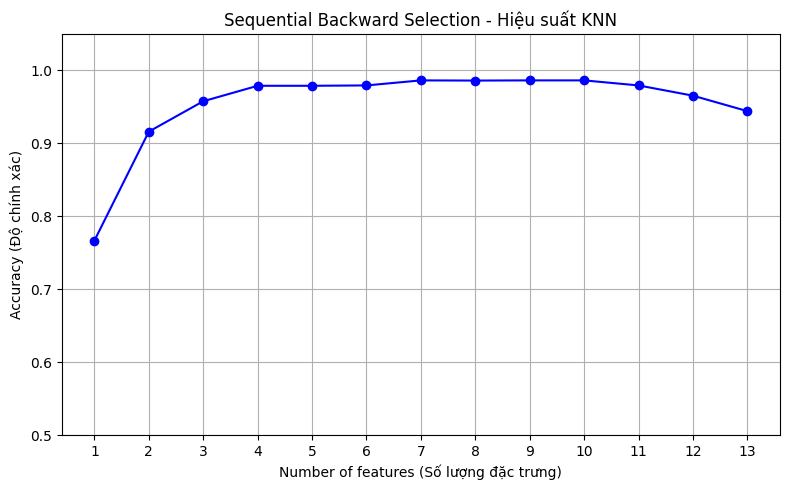

Index(['malic_acid', 'nonflavanoid_phenols', 'od280/od315_of_diluted_wines'], dtype='object')


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS_CV(estimator=knn, k_features=1)
sbs.fit(X_train_scaled, y_train)
k_feat = [len(k) for k in sbs.subsets_]
plt.figure(figsize=(8, 5))
plt.plot(k_feat, sbs.scores_, marker='o', linestyle='-', color='b')
plt.ylim([0.5, 1.05])
plt.ylabel('Accuracy (Độ chính xác)')
plt.xlabel('Number of features (Số lượng đặc trưng)')
plt.title('Sequential Backward Selection - Hiệu suất KNN')
plt.xticks(k_feat) # Hiển thị rõ từng mốc số lượng đặc trưng trên trục X
plt.grid(True)
plt.tight_layout()
plt.show()

k3 = list(sbs.subsets_[10])
print(X.columns[1:][k3])

# Đánh giá sự quan trọng của các đặc trưng thông qua Random Forest

 1) proline                        0.162982
 2) color_intensity                0.156167
 3) flavanoids                     0.144798
 4) alcohol                        0.138256
 5) od280/od315_of_diluted_wines   0.126075
 6) hue                            0.076362
 7) total_phenols                  0.060252
 8) alcalinity_of_ash              0.032791
 9) magnesium                      0.030406
10) malic_acid                     0.027107
11) proanthocyanins                0.024739
12) nonflavanoid_phenols           0.010813
13) ash                            0.009251


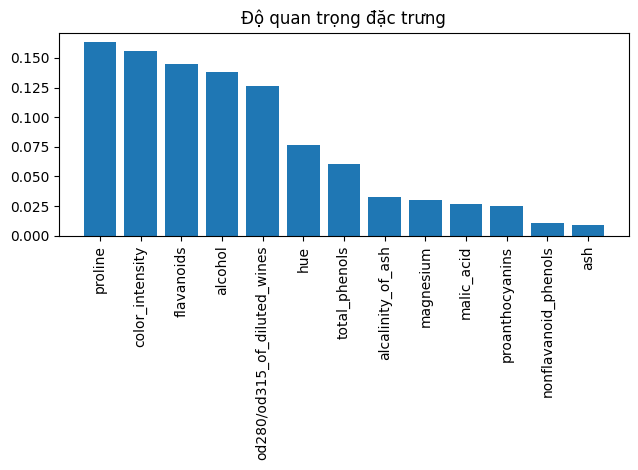

In [ ]:
from sklearn.ensemble import RandomForestClassifier

feat_labels = X.columns

forest = RandomForestClassifier(n_estimators=500,
                                random_state=1)

forest.fit(X_train, y_train)
importances = forest.feature_importances_

indices = np.argsort(importances)[::-1]

for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,
                            feat_labels[indices[f]],
                            importances[indices[f]]))

plt.title('Độ quan trọng đặc trưng')
plt.bar(range(X_train.shape[1]),
        importances[indices],
        align='center')

plt.xticks(range(X_train.shape[1]),
           feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import SelectFromModel

sfm = SelectFromModel(forest, threshold=0.1, prefit=True)
X_selected = sfm.transform(X_train_scaled)
print('Số lượng đặc trưng thoả mãn threshold:',
      X_selected.shape[1])

Số lượng đặc trưng thoả mãn threshold: 5
